In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Cancer_Data.csv to Cancer_Data (12).csv


In [ ]:
import pandas as pd
import numpy as np

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully!
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



Column names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Missing values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se       

In [ ]:
print("Columns in your dataset:")

for i, column in enumerate(df.columns):
    print(i, ":", column)

Columns in your dataset:
0 : id
1 : diagnosis
2 : radius_mean
3 : texture_mean
4 : perimeter_mean
5 : area_mean
6 : smoothness_mean
7 : compactness_mean
8 : concavity_mean
9 : concave points_mean
10 : symmetry_mean
11 : fractal_dimension_mean
12 : radius_se
13 : texture_se
14 : perimeter_se
15 : area_se
16 : smoothness_se
17 : compactness_se
18 : concavity_se
19 : concave points_se
20 : symmetry_se
21 : fractal_dimension_se
22 : radius_worst
23 : texture_worst
24 : perimeter_worst
25 : area_worst
26 : smoothness_worst
27 : compactness_worst
28 : concavity_worst
29 : concave points_worst
30 : symmetry_worst
31 : fractal_dimension_worst
32 : Unnamed: 32


In [ ]:
TARGET_COLUMN = "diagnosis"

print("Target column:", TARGET_COLUMN)
print(df[TARGET_COLUMN].value_counts())

Target column: diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# ==========================================
# STEP 1: CLEAN DATASET
# ==========================================

# Remove unnecessary columns if they exist
columns_to_remove = []

for col in ["id", "ID", "Unnamed: 32"]:
    if col in df.columns:
        columns_to_remove.append(col)

if columns_to_remove:
    df = df.drop(columns=columns_to_remove)

# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values
categorical_columns = df.select_dtypes(exclude=np.number).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Data cleaning completed!")
print("Dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())


# ==========================================
# CREATE FEATURES AND TARGET
# ==========================================

TARGET_COLUMN = "diagnosis"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Data cleaning completed!
Dataset shape: (569, 31)
Remaining missing values: 0

X shape: (569, 30)
y shape: (569,)

Target values:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# ==========================================
# STEP 2: ENCODE TARGET
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Target encoding completed!")

print("\nOriginal classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y))

Target encoding completed!

Original classes:
['B' 'M']

Encoded classes:
[0 1]


In [ ]:
# ==========================================
# STEP 3: ENCODE FEATURES
# ==========================================

X = pd.get_dummies(X, drop_first=True)

print("Feature encoding completed!")
print("Final X shape:", X.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature encoding completed!
Final X shape: (569, 30)

Feature columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [ ]:
# ==========================================
# STEP 4: TRAIN TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Data split completed!")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data split completed!
Training samples: 455
Testing samples: 114


In [ ]:
# ==========================================
# STEP 5: TRAIN MODEL
# ==========================================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# ==========================================
# STEP 6: MODEL PREDICTION
# ==========================================

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("==========================================")
print("       CANCER DISEASE PREDICTION")
print("==========================================")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

       CANCER DISEASE PREDICTION
Model Accuracy: 96.49%


In [ ]:
# ==========================================
# STEP 7: CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print("Classification Report:")
print()

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Classification Report:

              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



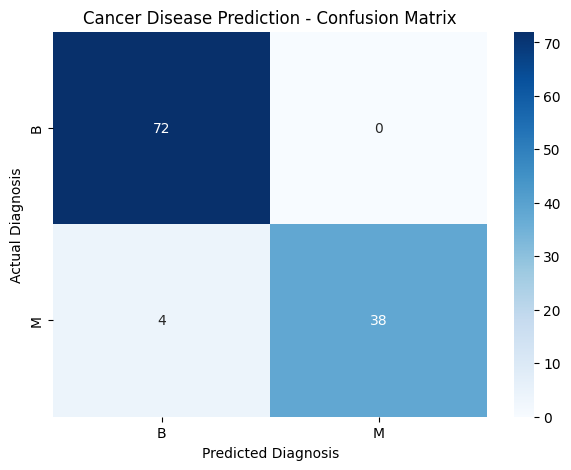

In [ ]:
# ==========================================
# STEP 8: CONFUSION MATRIX
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.title("Cancer Disease Prediction - Confusion Matrix")

plt.show()

In [ ]:
# ==========================================
# STEP 9: PATIENT PREDICTION
# ==========================================

patient = X_test.iloc[[0]]

prediction = model.predict(patient)

probability = model.predict_proba(patient)

predicted_class = label_encoder.inverse_transform(prediction)[0]

confidence = np.max(probability[0]) * 100

print("==========================================")
print("          PATIENT PREDICTION")
print("==========================================")

print("Predicted Diagnosis:", predicted_class)
print(f"Prediction Confidence: {confidence:.2f}%")

          PATIENT PREDICTION
Predicted Diagnosis: B
Prediction Confidence: 98.50%


In [ ]:
# ==========================================
# STEP 10: FINAL RESULT
# ==========================================

if predicted_class == "M":
    print("\nResult: Malignant")
    print("The model predicts a malignant cancer class.")

elif predicted_class == "B":
    print("\nResult: Benign")
    print("The model predicts a benign cancer class.")

else:
    print("\nPredicted Class:", predicted_class)


Result: Benign
The model predicts a benign cancer class.


In [ ]:
# ==========================================
# STEP 11: SAVE MODEL
# ==========================================

import joblib

joblib.dump(model, "/content/cancer_prediction_model.pkl")
joblib.dump(label_encoder, "/content/cancer_label_encoder.pkl")
joblib.dump(X.columns.tolist(), "/content/cancer_features.pkl")

print("==========================================")
print("Model saved successfully!")
print("==========================================")

Model saved successfully!
